# Some ideas for the metrics

## Init and simulation

In [1]:
import os

import pandas as pd

import leaspy
from leaspy.io.data import Data
from leaspy.models import JointModel

leaspy_root = os.path.dirname(leaspy.__file__)

data_path = os.path.join(leaspy_root, "datasets/data/simulated_data_for_joint.csv")

df = pd.read_csv(data_path, dtype={"ID": str}, sep=";")
display(df.head())
print(df.columns)
print("Unique IDs:", len(df["ID"].unique()))

data = Data.from_dataframe(df, "joint")
model = JointModel(name="test_model", nb_events=1)

,ID,TIME,EVENT_TIME,EVENT_BOOL,Y0,Y1,Y2,Y3
0,116,78.461,85.5,1,0.44444,0.04,0.0,0.0
1,116,78.936,85.5,1,0.60000,0.00,0.0,0.2
2,116,79.482,85.5,1,0.39267,0.04,0.0,0.2
3,116,79.939,85.5,1,0.58511,0.00,0.0,0.0
4,116,80.491,85.5,1,0.57044,0.00,0.0,0.0


Index(['ID', 'TIME', 'EVENT_TIME', 'EVENT_BOOL', 'Y0', 'Y1', 'Y2', 'Y3'], dtype='object')
Unique IDs: 17


In [2]:
model.fit(data, "mcmc_saem", seed=1312, n_iter=500, progress_bar=False)

/Users/jv.martini/Documents/leaspy/src/leaspy/models/time_reparametrized.py:288: UserWarning: You did not provide `source_dimension` hyperparameter for multivariate model, setting it to ⌊√dimension⌋ = 2.
  warnings.warn(


 ==> Setting seed to 1312


/Users/jv.martini/Library/Caches/pypoetry/virtualenvs/leaspy-c-kQpk1h-py3.12/lib/python3.12/site-packages/torch/__init__.py:696: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)



Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 13s


In [3]:
visit_params = {
    "patient_number": df["ID"].nunique(),
    "visit_type": "random",
    "first_visit_mean": 0.0,
    "first_visit_std": 0.4,
    "time_follow_up_mean": 6,  
    "time_follow_up_std": 1.2,
    "distance_visit_mean": 2 / 12,
    "distance_visit_std": 0.75 / 12,
    "min_spacing_between_visits": 1,
}

In [4]:
df_sim = model.simulate(
    algorithm="joint_simulate",
    features=["Y0", "Y1", "Y2", "Y3"],
    visit_parameters=visit_params,
)
df_sim = df_sim.data.to_dataframe()

display(df_sim)


Simulate with `joint_simulate` took: 0s


,ID,TIME,EVENT_TIME,EVENT_BOOL,Y0,Y1,Y2,Y3
0,0,76.0,78.652199,1,0.564005,1.029573e-04,1.477032e-01,0.141416
1,0,77.0,78.652199,1,0.660906,6.522695e-02,1.461071e-01,0.302516
2,0,78.0,78.652199,1,0.707631,2.255063e-01,2.555324e-01,0.376017
3,1,76.0,81.941246,1,0.619485,1.998525e-08,5.948373e-07,0.362972
4,1,77.0,81.941246,1,0.435354,2.893412e-03,4.440555e-04,0.385821
...,...,...,...,...,...,...,...,...
85,15,77.0,77.993446,1,0.755295,2.326981e-01,2.889768e-01,0.536983
86,16,83.0,86.634949,1,0.475900,3.059108e-01,1.122353e-10,0.610780
87,16,84.0,86.634949,1,0.411496,1.183114e-04,4.067680e-01,0.683893
88,16,85.0,86.634949,1,0.846075,8.096214e-02,2.129069e-01,0.800922


## More sophisticated metrics

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

In [6]:
def marginal_comparison(df, df_sim, col, ax, title=None):
    """Overlay KDE (continuous) or bar chart (discrete) for one variable."""
    a, b = df[col].dropna().values, df_sim[col].dropna().values
    
    for arr, label, color in [(a, 'Original', 'steelblue'), (b, 'Simulated', 'coral')]:
        kde = stats.gaussian_kde(arr)
        xs = np.linspace(min(arr.min(), b.min()), max(arr.max(), b.max()), 300)
        ax.plot(xs, kde(xs), label=label, color=color, lw=2)
        ax.fill_between(xs, kde(xs), alpha=0.15, color=color)
    
    ks_stat, ks_p = ks_2samp(a, b)
    wass = wasserstein_distance(a, b)
    ax.set_title(f"{title or col}\nKS={ks_stat:.3f} (p={ks_p:.3f})  |  Wasserstein={wass:.4f}", fontsize=10)
    ax.legend(fontsize=9)
    ax.set_ylabel('Density / Frequency')
    return {'variable': col, 'KS_stat': round(ks_stat, 4), 'KS_pvalue': round(ks_p, 4),
            'Wasserstein': round(wass, 4)}

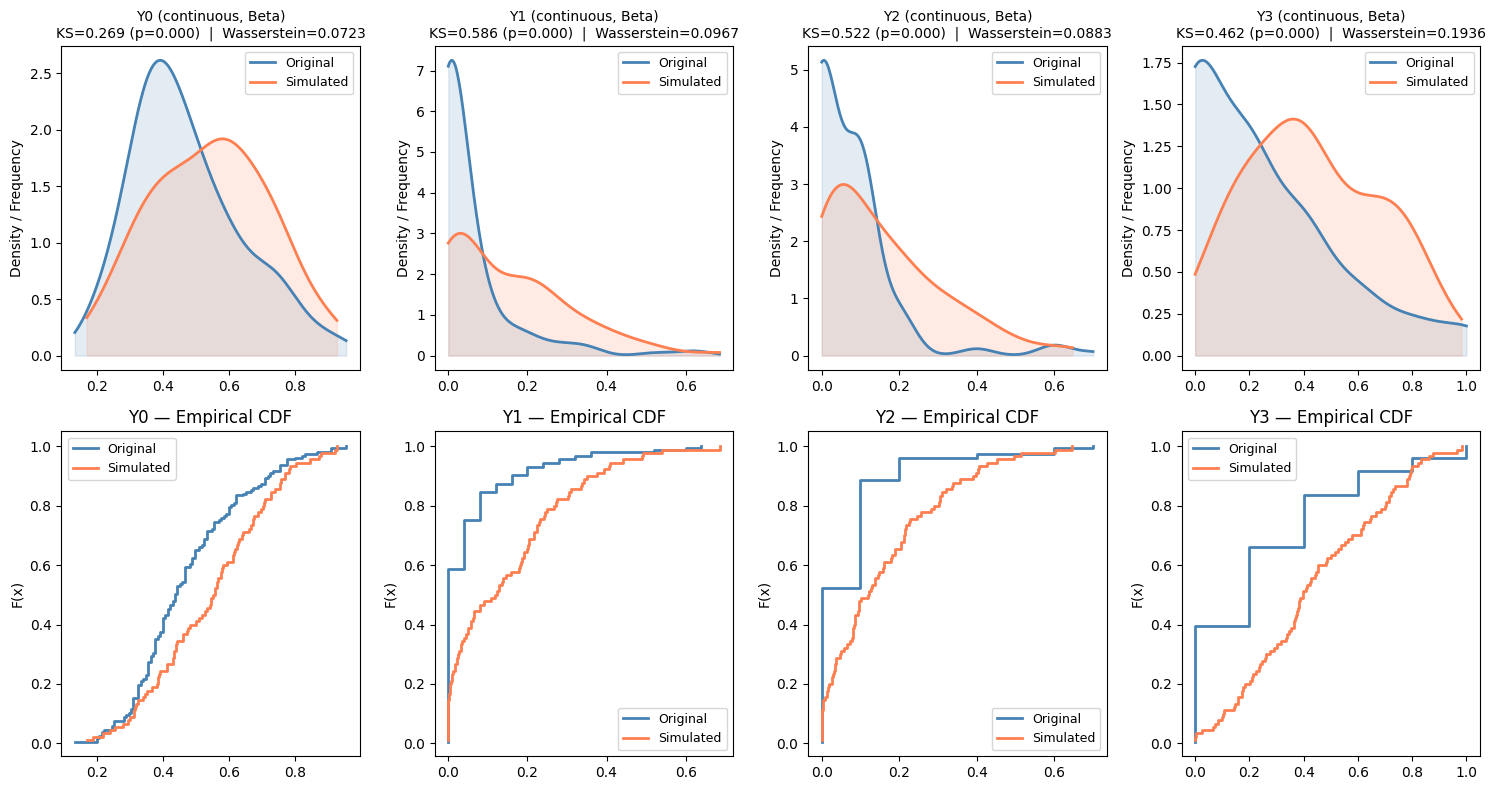

In [7]:
# 2 rows × 3 cols: top row = KDE, bottom row = ECDF
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
results = []

for col, ax_kde, ax_cdf in zip(['Y0', 'Y1', 'Y2', 'Y3'], axes[0], axes[1]):
    # KDE panel
    r = marginal_comparison(df, df_sim, col, ax_kde, title=f'{col} (continuous, Beta)')
    results.append(r)

    # ECDF panel
    for src, label, color in [(df, 'Original', 'steelblue'), (df_sim, 'Simulated', 'coral')]:
        arr = np.sort(src[col].dropna().values)
        ys  = np.arange(1, len(arr) + 1) / len(arr)
        ax_cdf.step(arr, ys, where='post', label=label, color=color, lw=2)
    ax_cdf.set_title(f'{col} — Empirical CDF')
    ax_cdf.set_ylabel('F(x)')
    ax_cdf.legend(fontsize=9)

plt.tight_layout()
plt.show()

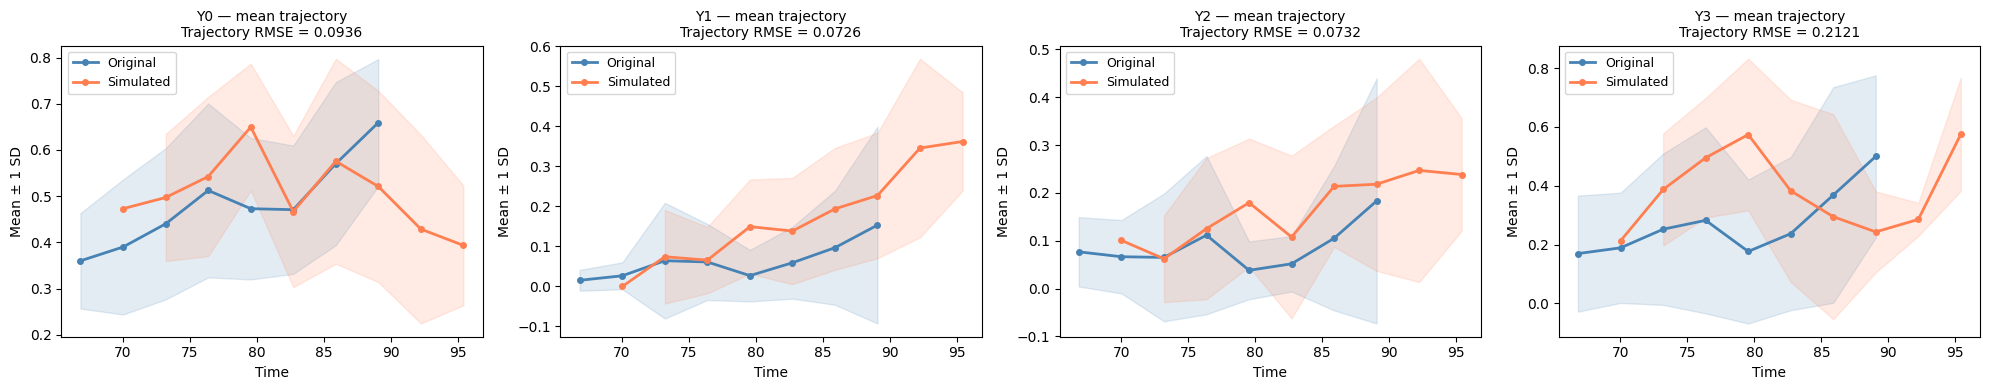

Trajectory RMSE per outcome: {'Y0': 0.0936, 'Y1': 0.0726, 'Y2': 0.0732, 'Y3': 0.2121}


In [8]:

def trajectory_comparison(df, df_sim, outcome_cols, n_bins=10):
    all_times = pd.concat([df['TIME'], df_sim['TIME']])
    bins = pd.cut(all_times, bins=n_bins)
    all_bin_cats = bins.cat.categories          # full ordered set of bins
    bin_centers = [iv.mid for iv in all_bin_cats]

    fig, axes = plt.subplots(1, len(outcome_cols), figsize=(5 * len(outcome_cols), 4))
    if len(outcome_cols) == 1:
        axes = [axes]

    traj_metrics = {}
    for ax, col in zip(axes, outcome_cols):
        for src, label, color in [(df, 'Original', 'steelblue'), (df_sim, 'Simulated', 'coral')]:
            src2 = src.copy()
            src2['_bin'] = pd.cut(src2['TIME'], bins=all_bin_cats)
            grp = src2.groupby('_bin', observed=False)[col]   # observed=False keeps empty bins
            means = grp.mean().reindex(all_bin_cats).values
            sds   = grp.std().reindex(all_bin_cats).values
            ax.plot(bin_centers, means, marker='o', ms=4, lw=2, label=label, color=color)
            ax.fill_between(bin_centers,
                            np.where(np.isnan(means - sds), np.nan, means - sds),
                            np.where(np.isnan(means + sds), np.nan, means + sds),
                            alpha=0.15, color=color)

        # RMSE on bin means (shared bins only)
        df2  = df.copy(); df2['_bin'] = pd.cut(df2['TIME'], bins=all_bin_cats)
        ds2  = df_sim.copy(); ds2['_bin'] = pd.cut(ds2['TIME'], bins=all_bin_cats)
        m_orig = df2.groupby('_bin', observed=False)[col].mean().reindex(all_bin_cats)
        m_sim  = ds2.groupby('_bin', observed=False)[col].mean().reindex(all_bin_cats)
        shared = m_orig.index.intersection(m_sim.index)
        rmse   = np.sqrt(np.nanmean((m_orig[shared].values - m_sim[shared].values)**2))
        traj_metrics[col] = round(rmse, 4)

        ax.set_title(f'{col} — mean trajectory\nTrajectory RMSE = {rmse:.4f}', fontsize=10)
        ax.set_xlabel('Time')
        ax.set_ylabel('Mean ± 1 SD')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    return traj_metrics

traj = trajectory_comparison(df, df_sim, ['Y0', 'Y1', 'Y2', 'Y3'])
print('Trajectory RMSE per outcome:', traj)


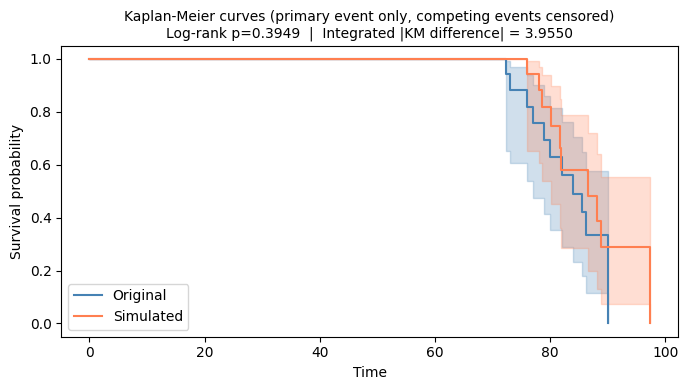

Survival metrics: {'logrank_pvalue': 0.3949, 'logrank_stat': 0.7239, 'integrated_KM_diff': 3.955}

Event-type rates (original):
EVENT_BOOL
censored         0.352941
primary event    0.647059

Event-type rates (simulated):
EVENT_BOOL
censored         0.411765
primary event    0.588235


In [9]:

# One row per patient
surv_orig = df.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']].dropna()
surv_sim  = df_sim.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']].dropna()

# EVENT_BOOL: 0 = censored, 1 = primary event, 2 = competing event.
# For the primary-event KM curve, competing events must be treated as censored (not as events).
surv_orig['event'] = (surv_orig['EVENT_BOOL'] == 1).astype(int)
surv_sim['event']  = (surv_sim['EVENT_BOOL'] == 1).astype(int)

kmf_orig = KaplanMeierFitter()
kmf_sim  = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(7, 4))
kmf_orig.fit(surv_orig['EVENT_TIME'], surv_orig['event'], label='Original')
kmf_sim.fit(surv_sim['EVENT_TIME'],  surv_sim['event'],  label='Simulated')
kmf_orig.plot_survival_function(ax=ax, ci_show=True, color='steelblue')
kmf_sim.plot_survival_function(ax=ax,  ci_show=True, color='coral')

lr = logrank_test(
    surv_orig['EVENT_TIME'], surv_sim['EVENT_TIME'],
    surv_orig['event'], surv_sim['event']
)

# Integrated KM difference (area between curves)
t_grid = np.linspace(
    min(surv_orig['EVENT_TIME'].min(), surv_sim['EVENT_TIME'].min()),
    max(surv_orig['EVENT_TIME'].max(), surv_sim['EVENT_TIME'].max()),
    500
)
s_orig = kmf_orig.survival_function_at_times(t_grid).values
s_sim  = kmf_sim.survival_function_at_times(t_grid).values
integrated_diff = np.trapz(np.abs(s_orig - s_sim), t_grid)

ax.set_title(
    f'Kaplan-Meier curves (primary event only, competing events censored)\n'
    f'Log-rank p={lr.p_value:.4f}  |  '
    f'Integrated |KM difference| = {integrated_diff:.4f}',
    fontsize=10
)
ax.set_xlabel('Time')
ax.set_ylabel('Survival probability')
plt.tight_layout()
plt.show()

survival_metrics = {
    'logrank_pvalue': round(lr.p_value, 4),
    'logrank_stat': round(lr.test_statistic, 4),
    'integrated_KM_diff': round(integrated_diff, 4)
}
print('Survival metrics:', survival_metrics)

# Event-type breakdown
print('\nEvent-type rates (original):')
print((surv_orig['EVENT_BOOL'].value_counts(normalize=True).sort_index()
       .rename({0: 'censored', 1: 'primary event', 2: 'competing event'})).to_string())
print('\nEvent-type rates (simulated):')
print((surv_sim['EVENT_BOOL'].value_counts(normalize=True).sort_index()
       .rename({0: 'censored', 1: 'primary event', 2: 'competing event'})).to_string())


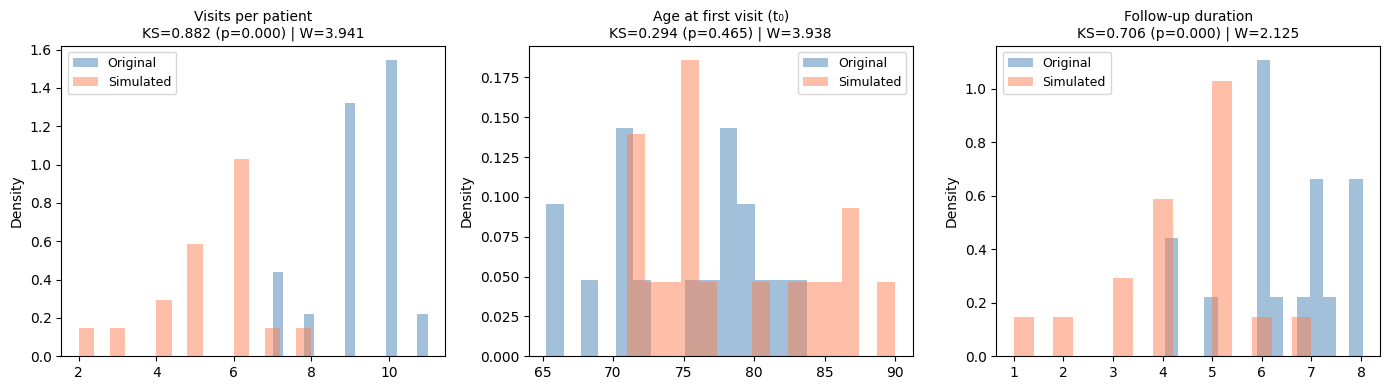

,Metric,Mean (orig),Mean (sim),SD (orig),SD (sim)
0,n_visits,9.235,5.294,1.091,1.448
1,age_first_visit,75.064,78.824,5.749,6.136
2,followup_duration,6.419,4.294,1.204,1.448


In [10]:
def visit_process_metrics(df, df_sim):
    n_orig = df.groupby('ID').size()
    n_sim  = df_sim.groupby('ID').size()

    t0_orig = df.groupby('ID')['TIME'].min()
    t0_sim  = df_sim.groupby('ID')['TIME'].min()

    fu_orig = df.groupby('ID')['TIME'].apply(lambda x: x.max() - x.min())
    fu_sim  = df_sim.groupby('ID')['TIME'].apply(lambda x: x.max() - x.min())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    metrics = {}

    for ax, (a, b, title) in zip(axes, [
        (n_orig, n_sim, 'Visits per patient'),
        (t0_orig, t0_sim, 'Age at first visit (t₀)'),
        (fu_orig, fu_sim, 'Follow-up duration'),
    ]):
        for arr, label, color in [(a.values, 'Original', 'steelblue'),
                                   (b.values, 'Simulated', 'coral')]:
            ax.hist(arr, bins=15, alpha=0.5, label=label, color=color, density=True)

        ks_stat, ks_p = ks_2samp(a.values, b.values)
        wass = wasserstein_distance(a.values, b.values)
        ax.set_title(f'{title}\nKS={ks_stat:.3f} (p={ks_p:.3f}) | W={wass:.3f}', fontsize=10)
        ax.legend(fontsize=9)
        ax.set_ylabel('Density')
        metrics[title] = {'KS_stat': round(ks_stat, 4), 'KS_p': round(ks_p, 4),
                          'Wasserstein': round(wass, 4)}

    plt.tight_layout()
    plt.show()

    # Summary table
    summary = pd.DataFrame({
        'Metric': ['n_visits', 'age_first_visit', 'followup_duration'],
        'Mean (orig)': [n_orig.mean(), t0_orig.mean(), fu_orig.mean()],
        'Mean (sim)':  [n_sim.mean(),  t0_sim.mean(),  fu_sim.mean()],
        'SD (orig)':   [n_orig.std(),  t0_orig.std(),  fu_orig.std()],
        'SD (sim)':    [n_sim.std(),   t0_sim.std(),   fu_sim.std()],
    }).round(3)
    return metrics, summary

visit_metrics, visit_summary = visit_process_metrics(df, df_sim)
display(visit_summary)

## Feature Correlation Structure

The joint model simulates correlated multivariate trajectories. Comparing the pairwise correlation matrices checks whether the inter-feature dependence structure is preserved.


Max  |Δcorr|: 0.6326
Mean |Δcorr|: 0.4029


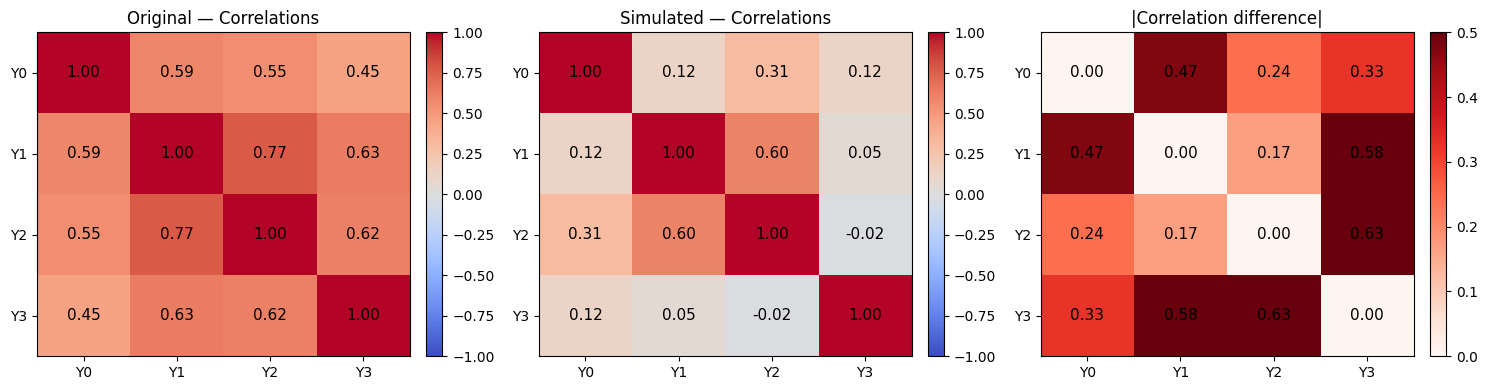

In [11]:

feat_cols = ['Y0', 'Y1', 'Y2', 'Y3']
corr_orig = df[feat_cols].corr()
corr_sim  = df_sim[feat_cols].corr()
corr_diff = (corr_orig - corr_sim).abs()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, corr, title, cmap, vmin, vmax in [
    (axes[0], corr_orig, 'Original — Correlations',     'coolwarm', -1, 1),
    (axes[1], corr_sim,  'Simulated — Correlations',    'coolwarm', -1, 1),
    (axes[2], corr_diff, '|Correlation difference|',    'Reds',      0, 0.5),
]:
    im = ax.imshow(corr.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(feat_cols))); ax.set_xticklabels(feat_cols)
    ax.set_yticks(range(len(feat_cols))); ax.set_yticklabels(feat_cols)
    for i in range(len(feat_cols)):
        for j in range(len(feat_cols)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=11)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

upper = np.triu_indices(len(feat_cols), k=1)
print(f'Max  |Δcorr|: {corr_diff.values[upper].max():.4f}')
print(f'Mean |Δcorr|: {corr_diff.values[upper].mean():.4f}')

plt.tight_layout()
plt.show()


## Competing Events — Cumulative Incidence Functions

With competing events, the Kaplan-Meier estimator is biased; the proper tool is the **Aalen-Johansen** estimator, which gives the cumulative incidence function (CIF) for each cause.


In [ ]:

from lifelines import AalenJohansenFitter

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, surv, label_prefix, color in [
    (axes[0], surv_orig, 'Original',  'steelblue'),
    (axes[1], surv_sim,  'Simulated', 'coral'),
]:
    # event_col: 0 = censored, 1 = primary, 2 = competing
    ajf = AalenJohansenFitter(calculate_variance=True)
    ajf.fit(surv['EVENT_TIME'], surv['EVENT_BOOL'], event_of_interest=1)
    ajf.plot_cumulative_density(ax=ax, label='CIF — primary event', color=color)

    ajf2 = AalenJohansenFitter(calculate_variance=True)
    ajf2.fit(surv['EVENT_TIME'], surv['EVENT_BOOL'], event_of_interest=2)
    ajf2.plot_cumulative_density(ax=ax, label='CIF — competing event', color=color,
                                  linestyle='--')

    ax.set_title(f'{label_prefix} — Cumulative Incidence Functions')
    ax.set_xlabel('Time')
    ax.set_ylabel('CIF')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
